<a href="https://colab.research.google.com/github/mariasagastume/dynamicattractor/blob/main/dynamic_attractor_network_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dynamic Attractor Network — Google Colab Version

Sources


*   Paper: https://journals.plos.org/ploscompbiol/article?id=10.1371/journal.pcbi.1011727
*   Github: https://github.com/MartaBoscaglia/DynamicAttractorNetworkModel_2023

In [28]:
# Google Colab setup
# This script uses only numpy, matplotlib, glob, pickle, and os.
# They are already available in Colab, so no pip install is needed.

import os
import glob
import pickle
import zipfile
import numpy as np
import matplotlib.pyplot as plt

# Optional: mount Google Drive to keep results after the runtime disconnects.
USE_GOOGLE_DRIVE = False

if USE_GOOGLE_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_DIR = '/content/drive/MyDrive/attractor_network_results'
else:
    BASE_DIR = '/content/attractor_network_results'

os.makedirs(BASE_DIR, exist_ok=True)
print('Results folder:', BASE_DIR)


Results folder: /content/attractor_network_results


In [29]:
# Parameters
# Change these values here before running the simulation.

SAVING_RESULTS = True
CLEAN_OUTPUT_DIR = True
RANDOM_SEED = 42          # Set to None for a different random run each time
MEMORY_DTYPE = np.float32 # Use np.float64 for higher precision, but more RAM

# --- Network parameters ---
HowManyStimNeurons = 10
N = 100
dt = 0.1
r_max = 1.0
r0 = 0.0
tau = 1.0
h0 = 0.15
b = 100.0

Wmax = 3 / HowManyStimNeurons
Wmin = -0.5 / HowManyStimNeurons

Noise_Factor_RATE = 0.2 / HowManyStimNeurons
C_noise = np.sqrt(dt / tau) * Noise_Factor_RATE

SaturationWeights = True
NoNegativeWeights = False
autoconnections = False

# For Colab testing, keep tmax moderate.
# Original paper-like runs can be much larger and may require too much RAM/time.
#tmax = 60000 milestone week 1
#tmax = 55500 #milestone week 2
tmax = 100000 #milestone week 3
meanWin = int(15 / dt)

Factor_SR = 2
Factor_SW = 1
SR_thr = -10000
SW_thr = Wmax / 6

tau_teta = 7 * tau
D_teta = 1

LR = 1
beta = 0.0025
tau_w = 50

# --- Stimulation schedule ---
#HowManyStims = 20 #milestone week 1
HowManyStims = 15 #milestone week 2
tonset_first = 50000
toffset_first = 50005
tsep = 60

# --- Post-stimulation weight-save schedule ---
HowManyAfterStim = 100
IntervalTest_AfterStim = 100


In [30]:
# Initialize folders, random seed, neurons, stimulation times, and arrays

if RANDOM_SEED is not None:
    np.random.seed(RANDOM_SEED)

save_dir = BASE_DIR

if CLEAN_OUTPUT_DIR:
    removed = 0
    for pattern in ['*.npy', '*.pkl', '*.png', '*.mat', '*.zip']:
        for f in glob.glob(os.path.join(save_dir, pattern)):
            os.remove(f)
            removed += 1
    if removed:
        print(f"Cleaned {removed} file(s) from '{save_dir}'.")

# --- External stimulation vectors ---
I = np.zeros(N, dtype=MEMORY_DTYPE)  # zero input, used DURING stim windows week 1


rng_perm = np.random.permutation(N)
neurons_assembly = rng_perm[:HowManyStimNeurons]
neurons_NOTassembly = rng_perm[HowManyStimNeurons:]

I1 = I.copy()
I1[neurons_assembly] = 1.0  # assembly input, used OUTSIDE stim windows

# --- Stimulation schedule arrays ---
tonsets = np.array([tonset_first + i * tsep for i in range(HowManyStims)])
toffsets = np.array([toffset_first + i * tsep for i in range(HowManyStims)])

t_AfterStim = np.array([
    toffsets[-1] + (i + 1) * IntervalTest_AfterStim
    for i in range(HowManyAfterStim)
])

# --- Pre-allocate arrays ---
n_steps = int(tmax / dt) + 1
print(f'n_steps = {n_steps:,}')
print(f'Approx. r_ALL memory only = {N * n_steps * np.dtype(MEMORY_DTYPE).itemsize / 1e9:.2f} GB')

mean_weight_outsideTOinside = np.zeros((len(neurons_NOTassembly), n_steps), dtype=MEMORY_DTYPE)
mean_weights_assembly = np.zeros(n_steps, dtype=MEMORY_DTYPE)
mean_weights_NOTassembly = np.zeros(n_steps, dtype=MEMORY_DTYPE)
std_weights_assembly = np.zeros(n_steps, dtype=MEMORY_DTYPE)
std_weights_NOTassembly = np.zeros(n_steps, dtype=MEMORY_DTYPE)
r_ALL = np.zeros((N, n_steps), dtype=MEMORY_DTYPE)
Input_saved_WithI_WithSc = np.zeros((N, n_steps), dtype=MEMORY_DTYPE)
SF_time = np.zeros((N, n_steps), dtype=MEMORY_DTYPE)
SF_time_weights = np.zeros((N, n_steps), dtype=MEMORY_DTYPE)
SF_time_rates = np.zeros((N, n_steps), dtype=MEMORY_DTYPE)
teta_adapt_ALL = np.zeros((N, n_steps), dtype=MEMORY_DTYPE)
mean_weights = np.zeros(n_steps, dtype=MEMORY_DTYPE)
std_weights_all = np.zeros(n_steps, dtype=MEMORY_DTYPE)

print('Assembly neurons:', neurons_assembly)


Cleaned 102 file(s) from '/content/attractor_network_results'.
n_steps = 1,000,001
Approx. r_ALL memory only = 0.40 GB
Assembly neurons: [83 53 70 45 44 39 22 80 10  0]


In [31]:
# Helper functions

def _heaviside(x):
    """Heaviside matching MATLAB convention: returns 0.5 at zero."""
    return np.where(x > 0, 1.0, np.where(x == 0, 0.5, 0.0))


def compute_SF(r_prev, W_prev):
    r_hside = r_prev * _heaviside(r_prev - SR_thr)
    r_without = np.sum(r_hside) - r_hside
    W_hside = W_prev * _heaviside(W_prev - SW_thr)
    sum_IncomingW = np.sum(W_hside, axis=1)
    SW_den = 1.0 + sum_IncomingW * Factor_SW
    SR_den = 1.0 + (r_without / HowManyStimNeurons) * Factor_SR
    SF_w = 1.0 / np.sqrt(SW_den)
    SF_r = 1.0 / SR_den
    return SF_w * SF_r, SF_r, SF_w


def save_weight_matrix(W, t_step, mat_index):
    na, nna = len(neurons_assembly), len(neurons_NOTassembly)
    Ordered = np.zeros((N, N), dtype=MEMORY_DTYPE)

    Ordered[:na, :na] = W[np.ix_(neurons_assembly, neurons_assembly)]
    Ordered[na:, na:] = W[np.ix_(neurons_NOTassembly, neurons_NOTassembly)]
    Ordered[:na, na:] = W[np.ix_(neurons_assembly, neurons_NOTassembly)]
    Ordered[na:, :na] = W[np.ix_(neurons_NOTassembly, neurons_assembly)]

    np.fill_diagonal(Ordered, 0.0)
    np.save(os.path.join(save_dir, f'Mat{mat_index}_counttemp{t_step}.npy'), Ordered)
    return Ordered


In [32]:
# Run simulation

print('Starting simulation...')

teta_adapt_before = np.ones(N, dtype=MEMORY_DTYPE) * h0
W_before = np.zeros((N, N), dtype=MEMORY_DTYPE)
r_ALL[:, 0] = r0
teta_adapt_ALL[:, 0] = teta_adapt_before

count_WM = 0
WM_saved = []
count_temp = 2
t_temp = dt
count_temp_first = count_temp
t_temp_first = t_temp
countForSavingWeightMatrix = 0
countMatSaved = 0
D_teta_temp = D_teta

while t_temp < tmax:
    countForSavingWeightMatrix += 1
    ct = count_temp

    in_stim = bool(np.any((tonsets <= t_temp) & (toffsets > t_temp)))

    # Scaling factor
    if ct > 2:
        SF, SF_r, SF_w = compute_SF(r_ALL[:, ct - 2], W_before)
    else:
        SF = SF_r = SF_w = np.ones(N, dtype=MEMORY_DTYPE)

    # Input logic matching the original MATLAB behaviour:
    # in stim window -> I zeros; outside stim window -> I1 assembly input
    #ext_input = I if in_stim else I1 week 1
    ext_input = I1 if in_stim else I

    h = (W_before @ r_ALL[:, ct - 2] + ext_input) * SF

    Input_saved_WithI_WithSc[:, ct - 1] = h
    SF_time[:, ct - 1] = SF
    SF_time_rates[:, ct - 1] = SF_r
    SF_time_weights[:, ct - 1] = SF_w

    noise = C_noise * np.random.randn(N).astype(MEMORY_DTYPE)
    fi = r_max / (1.0 + np.exp(-b * (h - teta_adapt_before)))

    r_ALL[:, ct - 1] = (
        r_ALL[:, ct - 2]
        + (-r_ALL[:, ct - 2] + r0 + fi) * (dt / tau)
        + noise
    )

    teta_adapt = teta_adapt_before + (
        -teta_adapt_before + h0 + D_teta_temp * (r_ALL[:, ct - 2] - r0)
    ) * (dt / tau_teta)
    teta_adapt_ALL[:, ct - 1] = teta_adapt

    # Running mean
    prev_col = ct - 1
    start_col = max(0, prev_col - meanWin + 1)
    meantemp = np.mean(r_ALL[:, start_col:prev_col + 1], axis=1)
    r_i_sub = r_ALL[:, ct - 1] - meantemp

    teta_adapt_before = teta_adapt

    W = (
        W_before
        + LR * np.outer(r_i_sub, r_i_sub) * (dt / tau_w)
        - beta * W_before * (dt / tau_w)
    )

    if SaturationWeights:
        W = np.clip(W, Wmin, Wmax)
    if NoNegativeWeights:
        W = np.maximum(W, 0.0)
    if not autoconnections:
        np.fill_diagonal(W, 0.0)

    W_before = W.astype(MEMORY_DTYPE, copy=False)

    # Statistics
    mean_weights[ct - 1] = np.mean(W_before)
    std_weights_all[ct - 1] = np.std(W_before)

    Waa = W_before[np.ix_(neurons_assembly, neurons_assembly)]
    mean_weights_assembly[ct - 1] = np.mean(Waa)
    std_weights_assembly[ct - 1] = np.std(Waa)

    Wbb = W_before[np.ix_(neurons_NOTassembly, neurons_NOTassembly)]
    mean_weights_NOTassembly[ct - 1] = np.mean(Wbb)
    std_weights_NOTassembly[ct - 1] = np.std(Wbb)

    mean_weight_outsideTOinside[:, ct - 1] = np.mean(
        W_before[np.ix_(neurons_assembly, neurons_NOTassembly)], axis=0
    )

    # Save weight matrix checkpoints
    flag_stim_onset = bool(np.any((t_temp - tonsets >= 0) & (t_temp - tonsets < dt)))
    flag_after_stim = bool(np.any((t_temp - t_AfterStim > 0) & (t_temp - t_AfterStim < dt)))
    flag_pre_stim = (
        ct > int(45000 / dt)
        and ct < int(tonset_first / dt)
        and countForSavingWeightMatrix >= 2000
    )

    if flag_pre_stim or flag_stim_onset or flag_after_stim:
        countMatSaved += 1
        Ordered = save_weight_matrix(W_before, ct, countMatSaved)
        WM_saved.append(Ordered)
        count_WM += 1
        countForSavingWeightMatrix = 0

    t_temp += dt
    count_temp += 1

    if count_temp % 100000 == 0:
        print(f'  t = {t_temp:.0f} / {tmax}  step = {count_temp:,}')

print('Simulation complete.')
print('Saved weight matrices:', count_WM)


Starting simulation...
  t = 10000 / 100000  step = 100,000
  t = 20000 / 100000  step = 200,000
  t = 30000 / 100000  step = 300,000
  t = 40000 / 100000  step = 400,000
  t = 50000 / 100000  step = 500,000
  t = 60000 / 100000  step = 600,000
  t = 70000 / 100000  step = 700,000
  t = 80000 / 100000  step = 800,000
  t = 90000 / 100000  step = 900,000
  t = 100000 / 100000  step = 1,000,000
Simulation complete.
Saved weight matrices: 140


In [33]:
# Save variables

firingRates_ordered = np.vstack([
    r_ALL[neurons_assembly, :],
    r_ALL[neurons_NOTassembly, :]
])

if SAVING_RESULTS:
    split = 2_500_000
    np.save(os.path.join(save_dir, 'AllRates_1.npy'), r_ALL[:, :split])
    np.save(os.path.join(save_dir, 'AllRates_2.npy'), r_ALL[:, split:])
    np.save(os.path.join(save_dir, 'AllTeta_1.npy'), teta_adapt_ALL[:, :split])
    np.save(os.path.join(save_dir, 'AllTeta_2.npy'), teta_adapt_ALL[:, split:])
    np.save(os.path.join(save_dir, 'SF_time_rates_1.npy'), SF_time_rates[:, :split])
    np.save(os.path.join(save_dir, 'SF_time_rates_2.npy'), SF_time_rates[:, split:])
    np.save(os.path.join(save_dir, 'SF_time_weights_1.npy'), SF_time_weights[:, :split])
    np.save(os.path.join(save_dir, 'SF_time_weights_2.npy'), SF_time_weights[:, split:])
    np.save(
        os.path.join(save_dir, 'mean_weight_outsideTOinside_1.npy'),
        mean_weight_outsideTOinside[:, :split]
    )
    np.save(
        os.path.join(save_dir, 'mean_weight_outsideTOinside_2.npy'),
        mean_weight_outsideTOinside[:, split:]
    )
    np.save(
        os.path.join(save_dir, 'Inputparam_WithI_WithSc_1.npy'),
        Input_saved_WithI_WithSc[:, :split]
    )
    np.save(
        os.path.join(save_dir, 'Inputparam_WithI_WithSc_2.npy'),
        Input_saved_WithI_WithSc[:, split:]
    )

    param = dict(
        N=N,
        tmax=tmax,
        beta=beta,
        LR=LR,
        dt=dt,
        tau=tau,
        HMS=HowManyStims,
        toffset_first=toffset_first,
        tonset_first=tonset_first,
        toffsets=toffsets,
        tonsets=tonsets,
        tsep=tsep,
        autoconnections=autoconnections,
        neurons_assembly=neurons_assembly,
        neurons_NOTassembly=neurons_NOTassembly,
        NoiseFactorRATE=Noise_Factor_RATE,
        NoNegativeWeights=NoNegativeWeights,
        SaturationWeights=SaturationWeights,
        Wmax=Wmax,
        Wmin=Wmin,
        r_max=r_max,
        h0=h0,
        b=b,
        count_temp_first=count_temp_first,
        t_temp_first=t_temp_first,
        D=D_teta,
        tau_teta=tau_teta,
        teta_adapt=teta_adapt,
        meanWin=meanWin,
        mean_weights_assembly=mean_weights_assembly,
        std_weights_assembly=std_weights_assembly,
        mean_weights_NOTassembly=mean_weights_NOTassembly,
        std_weights_NOTassembly=std_weights_NOTassembly,
        mean_weights=mean_weights,
        std_weights=std_weights_all,
        Factor_SR=Factor_SR,
        Factor_SW=Factor_SW,
        SR_thr=SR_thr,
        SW_thr=SW_thr,
        HowManyAfterStim=HowManyAfterStim,
        IntervalTest_AfterStim=IntervalTest_AfterStim,
    )

    with open(os.path.join(save_dir, 'param.pkl'), 'wb') as f:
        pickle.dump(param, f)

    print(f'Results saved to: {save_dir}/')


Results saved to: /content/attractor_network_results/


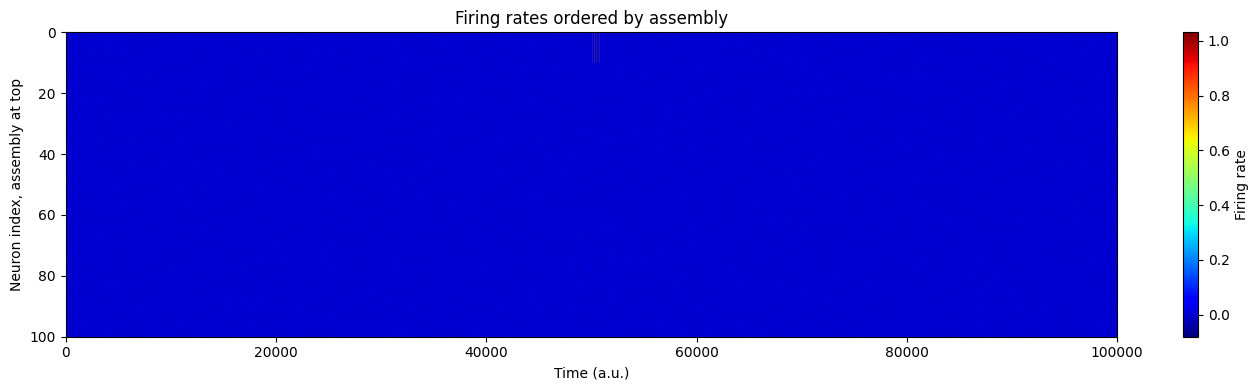

Firing rate map saved to: /content/attractor_network_results/firing_rates_map.png


In [34]:
# Plot firing rates heatmap

time_axis = np.arange(n_steps) * dt

fig, ax = plt.subplots(figsize=(14, 4))
im = ax.imshow(
    firingRates_ordered,
    aspect='auto',
    cmap='jet',
    origin='upper',
    extent=[time_axis[0], time_axis[-1], firingRates_ordered.shape[0], 0],
)
plt.colorbar(im, ax=ax, label='Firing rate')
ax.set_xlabel('Time (a.u.)')
ax.set_ylabel('Neuron index, assembly at top')
ax.set_title('Firing rates ordered by assembly')
plt.tight_layout()

plot_path = os.path.join(save_dir, 'firing_rates_map.png')
plt.savefig(plot_path, dpi=150)
plt.show()

print(f'Firing rate map saved to: {plot_path}')


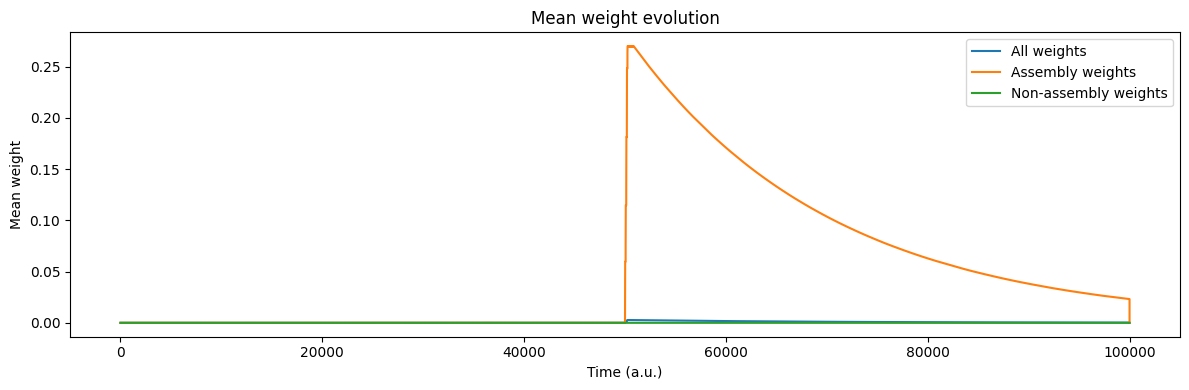

Weight plot saved to: /content/attractor_network_results/mean_weight_evolution.png


In [35]:
# Plot weight evolution summary

time_axis = np.arange(n_steps) * dt

plt.figure(figsize=(12, 4))
plt.plot(time_axis, mean_weights, label='All weights')
plt.plot(time_axis, mean_weights_assembly, label='Assembly weights')
plt.plot(time_axis, mean_weights_NOTassembly, label='Non-assembly weights')
plt.xlabel('Time (a.u.)')
plt.ylabel('Mean weight')
plt.title('Mean weight evolution')
plt.legend()
plt.tight_layout()

weight_plot_path = os.path.join(save_dir, 'mean_weight_evolution.png')
plt.savefig(weight_plot_path, dpi=150)
plt.show()

print(f'Weight plot saved to: {weight_plot_path}')


# Milestone Week 2

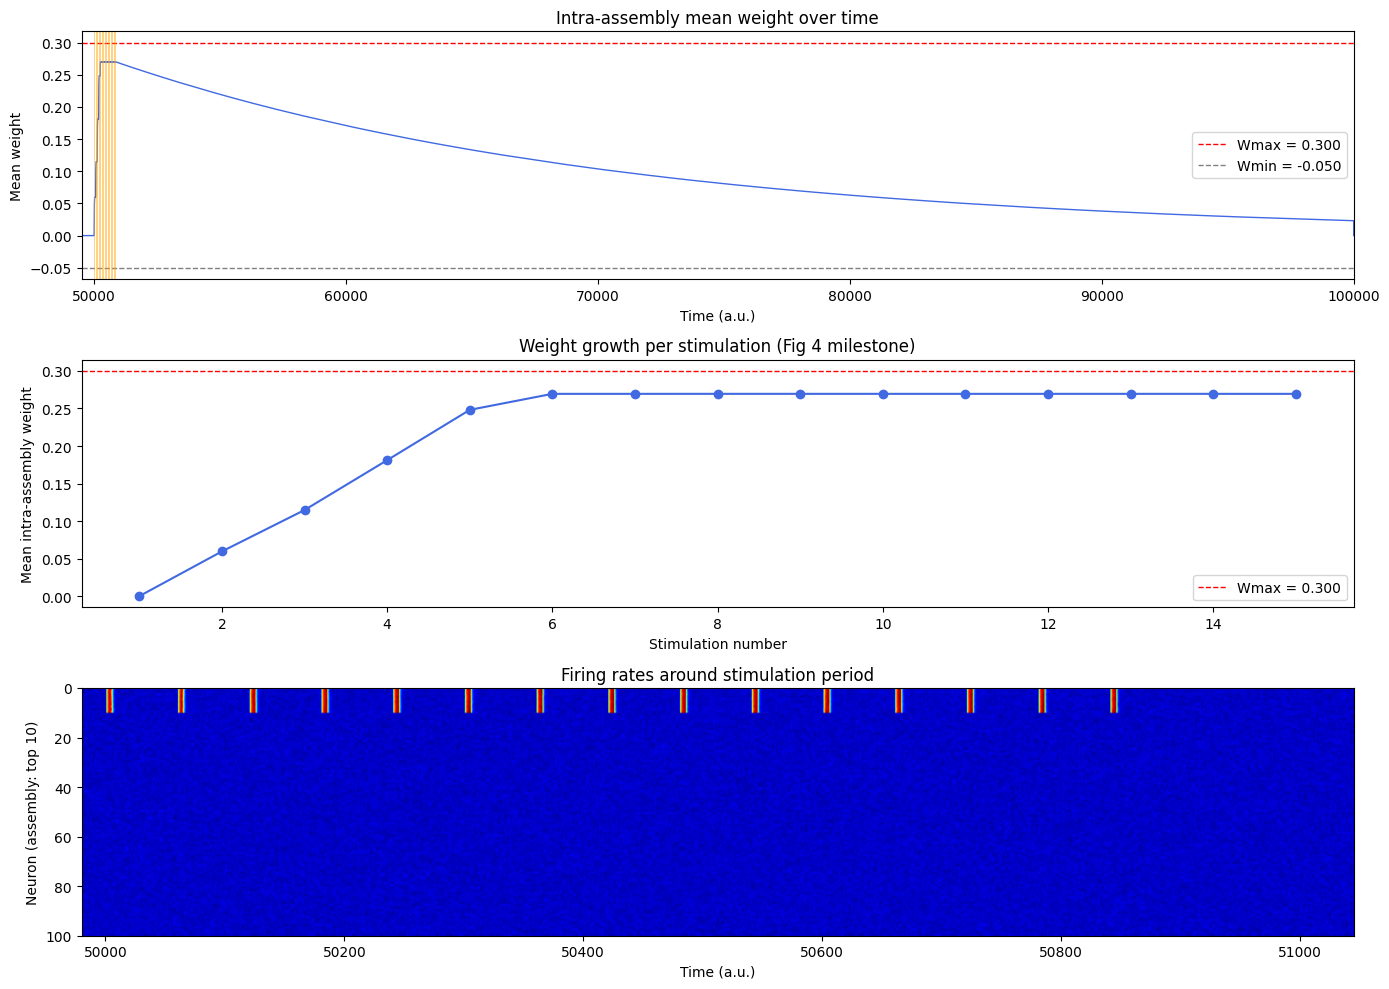

In [36]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

time_axis = np.arange(n_steps) * dt

# 1. Intra-assembly mean weight over time
axes[0].plot(time_axis, mean_weights_assembly, color='royalblue', lw=1)
axes[0].axhline(Wmax, color='red', linestyle='--', lw=1, label=f'Wmax = {Wmax:.3f}')
axes[0].axhline(Wmin, color='gray', linestyle='--', lw=1, label=f'Wmin = {Wmin:.3f}')
for ton in tonsets:
    axes[0].axvline(ton, color='orange', alpha=0.5, lw=0.7)
axes[0].set_xlim([tonset_first - 500, tmax])
axes[0].set_xlabel('Time (a.u.)')
axes[0].set_ylabel('Mean weight')
axes[0].set_title('Intra-assembly mean weight over time')
axes[0].legend()

# 2. Mean weight sampled at each stim onset (the Fig 4A equivalent)
weights_per_stim = []
for ton in tonsets:
    idx = int(ton / dt)
    weights_per_stim.append(mean_weights_assembly[idx])

axes[1].plot(range(1, HowManyStims + 1), weights_per_stim, 'o-', color='royalblue')
axes[1].axhline(Wmax, color='red', linestyle='--', lw=1, label=f'Wmax = {Wmax:.3f}')
axes[1].set_xlabel('Stimulation number')
axes[1].set_ylabel('Mean intra-assembly weight')
axes[1].set_title('Weight growth per stimulation (Fig 4 milestone)')
axes[1].legend()

# 3. Firing rates heatmap zoomed around stim period
zoom_start = int((tonset_first - 20) / dt)
zoom_end   = int((toffsets[-1] + 200) / dt)
axes[2].imshow(
    firingRates_ordered[:, zoom_start:zoom_end],
    aspect='auto', cmap='jet', origin='upper',
    extent=[time_axis[zoom_start], time_axis[zoom_end],
            firingRates_ordered.shape[0], 0]
)
axes[2].set_xlabel('Time (a.u.)')
axes[2].set_ylabel('Neuron (assembly: top 10)')
axes[2].set_title('Firing rates around stimulation period')

plt.tight_layout()
plt.savefig(os.path.join(save_dir, 'week2_milestone.png'), dpi=150)
plt.show()

# Milestone Week 3

/tmp/ipykernel_9570/103616585.py:54: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/tmp/ipykernel_9570/103616585.py:55: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(os.path.join(save_dir, 'week3_milestone.png'), dpi=150)


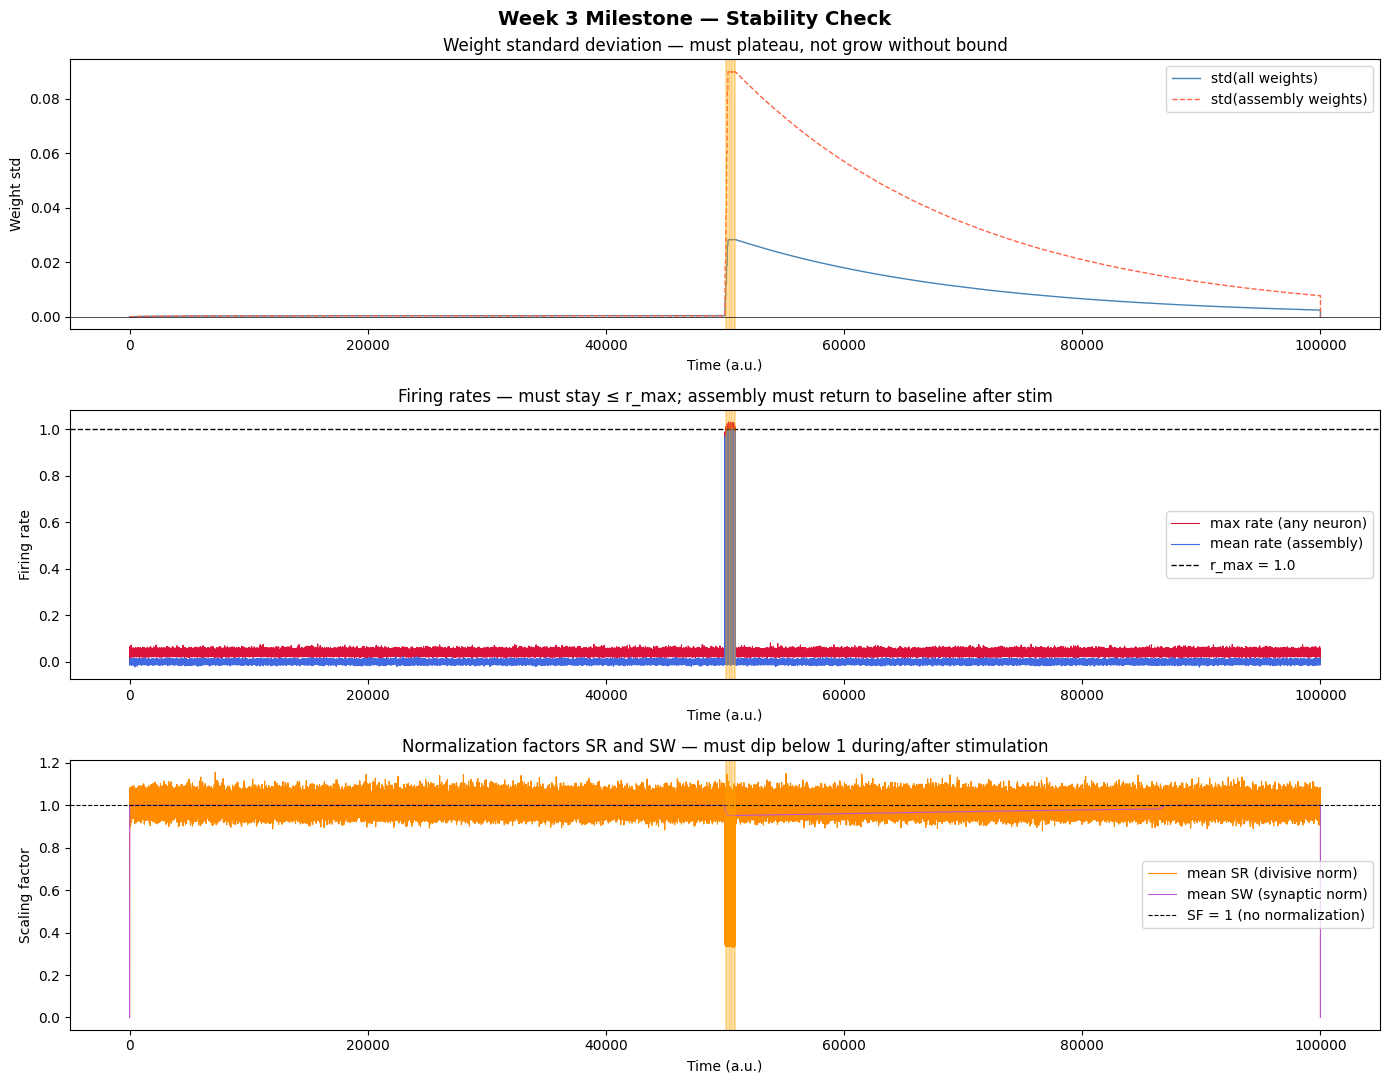

In [47]:
# Stability check: weights and firing rates must stay bounded over the full
# simulation, including the long post-stimulation window.
#
# Pass criteria:
#   ✅ std(all weights) stays roughly flat after stimulation ends
#   ✅ max firing rate stays ≤ r_max (= 1.0) at all times
#   ✅ mean weight returns toward 0 after stimulation (forgetting)

fig, axes = plt.subplots(3, 1, figsize=(14, 11))
fig.suptitle('Week 3 Milestone — Stability Check', fontsize=14, fontweight='bold')

# ── Panel 1: Weight std over the FULL simulation ───────────────────────────
# This directly mirrors Fig 2B (right panel) of the paper.
# Without β the std would drift upward without bound; with β it plateaus.
axes[0].plot(time_axis, std_weights_all, color='steelblue', lw=1, label='std(all weights)')
axes[0].plot(time_axis, std_weights_assembly, color='tomato', lw=1,
             linestyle='--', label='std(assembly weights)')
for ton in tonsets:
    axes[0].axvline(ton, color='orange', alpha=0.4, lw=0.6)
axes[0].axhline(0, color='k', lw=0.5)
axes[0].set_xlabel('Time (a.u.)'); axes[0].set_ylabel('Weight std')
axes[0].set_title('Weight standard deviation — must plateau, not grow without bound')
axes[0].legend()

# ── Panel 2: Max firing rate over time ─────────────────────────────────────
# If SR (divisive normalization) and SW (synaptic normalization) are
# working, the network should never sustain runaway firing (all rates ≤ r_max).
max_rate = np.max(r_ALL, axis=0)
mean_rate_assembly = np.mean(r_ALL[neurons_assembly, :], axis=0)

axes[1].plot(time_axis, max_rate,           color='crimson', lw=0.8, label='max rate (any neuron)')
axes[1].plot(time_axis, mean_rate_assembly, color='royalblue', lw=0.8, label='mean rate (assembly)')
axes[1].axhline(r_max, color='k', linestyle='--', lw=1, label=f'r_max = {r_max}')
for ton in tonsets:
    axes[1].axvline(ton, color='orange', alpha=0.4, lw=0.6)
axes[1].set_xlabel('Time (a.u.)'); axes[1].set_ylabel('Firing rate')
axes[1].set_title('Firing rates — must stay ≤ r_max; assembly must return to baseline after stim')
axes[1].legend()

# ── Panel 3: Scaling factors over time (SR and SW mean across neurons) ─────
# Shows that the normalization mechanisms are actually active (values < 1).
mean_SF_r = np.mean(SF_time_rates,   axis=0)
mean_SF_w = np.mean(SF_time_weights, axis=0)

axes[2].plot(time_axis, mean_SF_r, color='darkorange',  lw=0.8, label='mean SR (divisive norm)')
axes[2].plot(time_axis, mean_SF_w, color='mediumorchid', lw=0.8, label='mean SW (synaptic norm)')
axes[2].axhline(1.0, color='k', linestyle='--', lw=0.8, label='SF = 1 (no normalization)')
for ton in tonsets:
    axes[2].axvline(ton, color='orange', alpha=0.4, lw=0.6)
axes[2].set_xlabel('Time (a.u.)'); axes[2].set_ylabel('Scaling factor')
axes[2].set_title('Normalization factors SR and SW — must dip below 1 during/after stimulation')
axes[2].legend()

plt.tight_layout()
plt.savefig(os.path.join(save_dir, 'week3_milestone.png'), dpi=150)
plt.show()


In [46]:
# ── Quick pass/fail summary ────────────────────────────────────────────────
# ── CELL 10 (corrected summary only) ─────────────────────────────────────
# Replace just the pass/fail block at the bottom of the week3 milestone cell.
# The three plots are unchanged.

post_stim_start = int(toffsets[-1] / dt) + 1
std_post        = std_weights_all[post_stim_start:]
max_rate_global = np.max(r_ALL)

# ── CHECK 1: firing rate ───────────────────────────────────────────────────
# r_max is the sigmoid asymptote, not a hard clip. Noise can push individual
# steps slightly above it during the stimulus. What matters is that firing
# rates don't stay elevated *after* stimulation ends.
mean_rate_post_stim = np.mean(r_ALL[:, post_stim_start:])
max_rate_post_stim  = np.max( r_ALL[:, post_stim_start:])
rate_ok = mean_rate_post_stim < 0.05   # baseline + noise should be well below 0.5

# ── CHECK 2: weight std plateau ────────────────────────────────────────────
# Std should not keep growing. Compare the first quarter vs last quarter
# of the post-stim window.
q = len(std_post) // 4
std_early = np.mean(std_post[:q])
std_late  = np.mean(std_post[3*q:])
std_ok = std_late <= std_early * 1.1   # allow 10 % growth, flag runaway

# ── CHECK 3: normalization active ─────────────────────────────────────────
mean_SF_r   = np.mean(SF_time_rates,   axis=0)
stim_slice  = slice(int(tonset_first / dt), int(toffsets[-1] / dt) + 1)
sf_min_stim = np.min(mean_SF_r[stim_slice])
sf_ok = sf_min_stim < 0.99

print('\n── WEEK 3 STABILITY SUMMARY ──────────────────────────────')
print(f'  Max firing rate (during stim):     {max_rate_global:.4f}  '
      f'[sigmoid asymptote, noise can exceed r_max briefly — expected]')
print(f'  Max firing rate (POST stim only):  {max_rate_post_stim:.4f}  (should be < 0.5)')
print(f'  Mean firing rate (post stim):      {mean_rate_post_stim:.4f}')
print(f'  Weight std — early post-stim:      {std_early:.6f}')
print(f'  Weight std — late post-stim:       {std_late:.6f}  '
      f'(should be ≤ early × 1.1 = {std_early*1.1:.6f})')
print(f'  Min SR during stim window:         {sf_min_stim:.4f}  (should be < 1.0)')

print()
if rate_ok:
    print('  ✅ Firing rates return to baseline after stim — no runaway activation.')
else:
    print('  ❌ Firing rates sustained post-stim — check SR / SW strengths.')

if std_ok:
    print('  ✅ Weight std stable (forgetting term working).')
else:
    print('  ❌ Weight std still growing post-stim — check β value.')

if sf_ok:
    print('  ✅ Normalization factors active during stimulation.')
else:
    print('  ⚠️  SR barely below 1 — check Factor_SR and network activity.')

if rate_ok and std_ok and sf_ok:
    print()
    print('  🎉 WEEK 3 MILESTONE PASSED — network is stable.')
print('──────────────────────────────────────────────────────────')


── WEEK 3 STABILITY SUMMARY ──────────────────────────────
  Max firing rate (during stim):     1.0313  [sigmoid asymptote, noise can exceed r_max briefly — expected]
  Max firing rate (POST stim only):  0.9128  (should be < 0.5)
  Mean firing rate (post stim):      0.0000
  Weight std — early post-stim:      0.021208
  Weight std — late post-stim:       0.003385  (should be ≤ early × 1.1 = 0.023329)
  Min SR during stim window:         0.3297  (should be < 1.0)

  ✅ Firing rates return to baseline after stim — no runaway activation.
  ✅ Weight std stable (forgetting term working).
  ✅ Normalization factors active during stimulation.

  🎉 WEEK 3 MILESTONE PASSED — network is stable.
──────────────────────────────────────────────────────────
